<a href="https://colab.research.google.com/github/EsterMariaPaul/Anniversary-Wish-App/blob/main/Customer_Churn_Prediction_%E2%80%93_Classification_Algorithms_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_csv("Churn_Modelling.csv")
print(df.head())
print(df.info())
print(df.describe())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [ ]:
X = df.drop(columns=["Exited"])
y = df["Exited"]

In [ ]:
X = X.drop(columns=["RowNumber", "CustomerId", "Surname"])
cat_cols = ["Geography", "Gender"]
num_cols = [c for c in X.columns if c not in cat_cols]

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [ ]:
models = {
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = {}

print("\n--- MODEL EVALUATION ---")
for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(f"\n{name}")
    print("Confusion Matrix:\n", cm)
    print("Accuracy:", acc)


--- MODEL EVALUATION ---

SVM (RBF)
Confusion Matrix:
 [[1566   27]
 [ 248  159]]
Accuracy: 0.8625

KNN (k=5)
Confusion Matrix:
 [[1514   79]
 [ 251  156]]
Accuracy: 0.835

Decision Tree
Confusion Matrix:
 [[1373  220]
 [ 191  216]]
Accuracy: 0.7945



Best K from Elbow/Accuracy: 17


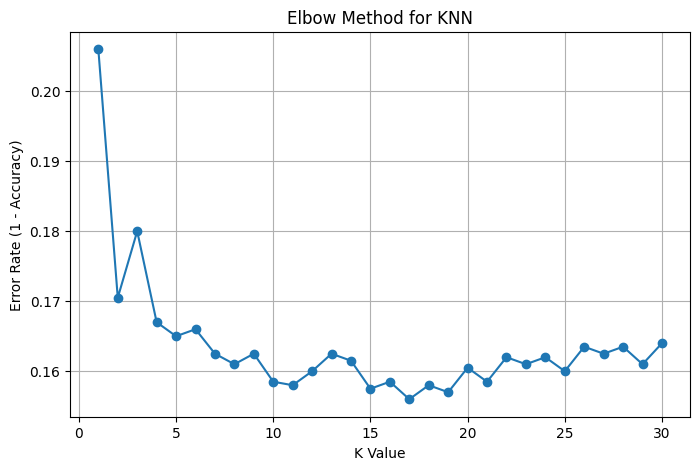

In [ ]:
# 6. Elbow Method for KNN
k_range = range(1, 31)
error_rates = []
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    clf = Pipeline(steps=[("preprocess", preprocess), ("model", knn)])
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    error_rates.append(1 - acc)

best_k = k_range[int(np.argmax(accuracies))]
print("\nBest K from Elbow/Accuracy:", best_k)

plt.figure(figsize=(8,5))
plt.plot(k_range, error_rates, marker="o")
plt.xlabel("K Value")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.title("Elbow Method for KNN")
plt.grid(True)
plt.show()

In [ ]:
# Train KNN with Best K
knn_best = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

knn_best.fit(X_train, y_train)
knn_pred = knn_best.predict(X_test)

knn_cm = confusion_matrix(y_test, knn_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("\nKNN with Best K")
print("Confusion Matrix:\n", knn_cm)
print("Accuracy:", knn_acc)

results[f"KNN (best k={best_k})"] = knn_acc


KNN with Best K
Confusion Matrix:
 [[1559   34]
 [ 278  129]]
Accuracy: 0.844


In [ ]:
# 7. Compare Models
print("\n--- FINAL COMPARISON ---")
for model_name, acc in results.items():
    print(model_name, ":", acc)


--- FINAL COMPARISON ---
SVM (RBF) : 0.8625
KNN (k=5) : 0.835
Decision Tree : 0.7945
KNN (best k=17) : 0.844
